# MGSC 661 - Predicting Movie Opening-Weekend Revenue


 

## Setup

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.pyplot import subplots
from IPython.display import display

import statsmodels.api as sm
from statsmodels.stats.outliers_influence import OLSInfluence
from statsmodels.stats.stattools import durbin_watson
from statsmodels.stats.diagnostic import het_white
from scipy.stats import shapiro

from ISLP.models import (ModelSpec as MS,
                         summarize)

In [2]:

df = pd.read_excel('movie_training_data_student.xlsx', sheet_name = 'Training_Data')
df.head()

,movie_id,title,release_date,release_year,release_month,release_quarter,opening_weekend_revenue_musd,production_budget_musd,opening_theaters,runtime_minutes,...,holiday_release,source_dataset,source_url,audience_score,domestic_box_office_musd,foreign_box_office_musd,worldwide_box_office_musd,opening_revenue_per_theater_kusd,opening_budget_recovery_pct,worldwide_budget_recovery_pct
0,TRN-0001,Escape Room,2019-01-04,2019,1,Q1,18.238172,9.0,2717,109.0,...,0,The Numbers release schedule and movie page; L...,https://www.the-numbers.com/movie/Escape-Room-...,54.0,57.00,98.61,155.62,6.712614,2.026464,17.291111
1,TRN-0002,A Dog’s Way Home,2019-01-11,2019,1,Q1,11.251263,61.0,3090,102.0,...,0,The Numbers release schedule and movie page; L...,https://www.the-numbers.com/movie/Dogs-Way-Hom...,71.0,41.95,39.20,81.15,3.641185,0.184447,1.330328
2,TRN-0003,Replicas,2019-01-11,2019,1,Q1,2.375325,30.0,2329,107.0,...,0,The Numbers release schedule and movie page,https://www.the-numbers.com/movie/Replicas-(2018),NaN,NaN,NaN,NaN,1.019891,0.079177,NaN
3,TRN-0004,Dragon Ball Super: Broly,2019-01-16,2019,1,Q1,9.816197,8.5,1247,100.0,...,0,The Numbers release schedule and movie page,https://www.the-numbers.com/movie/Dragon-Ball-...,NaN,NaN,NaN,NaN,7.871850,1.154847,NaN
4,TRN-0005,Glass,2019-01-18,2019,1,Q1,40.328920,20.0,3841,128.0,...,0,The Numbers release schedule and movie page; L...,https://www.the-numbers.com/movie/Glass-(2019),66.0,111.05,135.95,247.00,10.499589,2.016446,12.350000


# Part 1. Conduct an initial assessment of the data

## Question 1. Report the number of observations and variables

In [3]:
n_observations, n_variables = df.shape

print("Number of observations:", n_observations)
print("Number of variables:", n_variables)

Number of observations: 359
Number of variables: 29


## Question 2. Create a missing-value report

In [4]:
missing_number_by_column = df.isna().sum()
missing_percentage_by_column = missing_number_by_column / n_observations * 100


missing_report = pd.DataFrame({'missing_count': missing_number_by_column, 'missing_percentage': missing_percentage_by_column}).round(2)
missing_report


,missing_count,missing_percentage
movie_id,0,0.00
title,0,0.00
release_date,0,0.00
release_year,0,0.00
release_month,0,0.00
release_quarter,0,0.00
opening_weekend_revenue_musd,0,0.00
production_budget_musd,0,0.00
opening_theaters,0,0.00
runtime_minutes,5,1.39


## Question 3. Report descriptive statistics for the numerical variables

In [ ]:
numerical_variables = df.select_dtypes(include=[np.number]).columns

# Use .describe(), as in the introductory Python lab. Pandas ignores missing
# observations separately for each variable.
summary = df[numerical_variables].describe().T

descriptive_statistics = summary.round(3)

descriptive_statistics.index.name = "Variable"
descriptive_statistics


,count,mean,std,min,25%,50%,75%,max
Variable,,,,,,,,
release_year,359.0,2022.432,2.286,2019.000,2019.000,2023.000,2024.000,2025.000
release_month,359.0,6.735,3.415,1.000,4.000,7.000,10.000,12.000
opening_weekend_revenue_musd,359.0,29.555,41.378,0.251,6.504,13.190,30.832,357.115
production_budget_musd,359.0,67.761,71.837,0.015,18.000,40.500,95.000,400.000
opening_theaters,359.0,3211.900,876.190,660.000,2705.000,3354.000,3856.000,4735.000
runtime_minutes,354.0,115.384,20.588,84.000,101.000,112.000,126.750,197.000
summer_release,359.0,0.248,0.432,0.000,0.000,0.000,0.000,1.000
holiday_release,359.0,0.187,0.390,0.000,0.000,0.000,0.000,1.000
audience_score,202.0,79.460,15.032,31.000,71.000,83.000,92.000,99.000


# Part 2. Estimate and interpret the baseline model

## Question 4. Prepare the baseline-model sample

In [13]:
baseline_variables = [
    "opening_weekend_revenue_musd",
    "production_budget_musd",
    "opening_theaters",
    "runtime_minutes"
]

# Drop rows only when a variable required by this model is missing.
baseline_data = df[baseline_variables].dropna()

print("Baseline sample size:", baseline_data.shape[0])
print("Number of observations removed:", df.shape[0] - baseline_data.shape[0]) 

Baseline sample size: 354
Number of observations removed: 5


## Question 5. Estimate and report the full baseline model

In [17]:
baseline_predictors = [
    "production_budget_musd",
    "opening_theaters",
    "runtime_minutes"
]

design_baseline = MS(baseline_predictors)
X_baseline = design_baseline.fit_transform(baseline_data)
y_baseline = baseline_data["opening_weekend_revenue_musd"]

baseline_model = sm.OLS(y_baseline, X_baseline)
baseline_results = baseline_model.fit()

baseline_results.summary()  


<class 'statsmodels.iolib.summary.Summary'>
"""
                                 OLS Regression Results                                 
========================================================================================
Dep. Variable:     opening_weekend_revenue_musd   R-squared:                       0.526
Model:                                      OLS   Adj. R-squared:                  0.522
Method:                           Least Squares   F-statistic:                     129.6
Date:                          Wed, 23 Sep 2026   Prob (F-statistic):           1.75e-56
Time:                                  13:20:37   Log-Likelihood:                -1689.4
No. Observations:                           354   AIC:                             3387.
Df Residuals:                               350   BIC:                             3402.
Df Model:                                     3                                         
Covariance Type:                      nonrobust                                         
==========================================================================================
                             coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------
intercept                -48.7159     11.848     -4.112      0.000     -72.018     -25.414
production_budget_musd     0.2760      0.030      9.116      0.000       0.216       0.336
opening_theaters           0.0142      0.002      6.448      0.000       0.010       0.018
runtime_minutes            0.1242      0.086      1.439      0.151      -0.046       0.294
==============================================================================
Omnibus:                      181.590   Durbin-Watson:                   1.950
Prob(Omnibus):                  0.000   Jarque-Bera (JB):             1560.797
Skew:                           1.970   Prob(JB):                         0.00
Kurtosis:                      12.502   Cond. No.                     2.58e+04
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 2.58e+04. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

## Question 6. Interpret all coefficients in the baseline model

Holding the other variables constant, a $1 million increase in production budget is associated with a $0.276 million increase in predicted opening-weekend revenue. An additional opening theater is associated with a $0.0142 million, or $14,200, increase in predicted opening-weekend revenue. Holding budget and number of theaters constant, one additional minute of runtime is associated with a $0.124 million, or $12,420, increase in predicted revenue. However, runtime is not statistically significant at the 5% level (p = 0.151), so there is no sufficient evidence that runtime has a linear relationship with opening-weekend revenue in this model. The intercept is -$48.716 million, representing the predicted revenue when budget, opening theaters, and runtime are all zero. Since such a movie is unrealistic and outside the observed context, the intercept has little practical meaning.

## Question 7. Remove insignificant predictors and re-estimate the model

In [18]:
# Keep predictors with p-values below 0.05 in the full baseline model.
p_values = baseline_results.pvalues.drop("intercept")
significant_predictors = p_values[p_values < 0.05].index.tolist()
significant_predictors



['production_budget_musd', 'opening_theaters']

In [19]:
 #=======regression with significant predictors only=======
design_reduced = MS(significant_predictors)
X_reduced = design_reduced.fit_transform(baseline_data)
y_reduced = baseline_data["opening_weekend_revenue_musd"]
reduced_model = sm.OLS(y_reduced, X_reduced)
reduced_results = reduced_model.fit()
reduced_results.summary()  


<class 'statsmodels.iolib.summary.Summary'>
"""
                                 OLS Regression Results                                 
========================================================================================
Dep. Variable:     opening_weekend_revenue_musd   R-squared:                       0.524
Model:                                      OLS   Adj. R-squared:                  0.521
Method:                           Least Squares   F-statistic:                     192.8
Date:                          Wed, 23 Sep 2026   Prob (F-statistic):           3.12e-57
Time:                                  13:46:53   Log-Likelihood:                -1690.5
No. Observations:                           354   AIC:                             3387.
Df Residuals:                               351   BIC:                             3399.
Df Model:                                     2                                         
Covariance Type:                      nonrobust                                         
==========================================================================================
                             coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------
intercept                -34.2288      6.255     -5.472      0.000     -46.530     -21.927
production_budget_musd     0.2970      0.027     11.178      0.000       0.245       0.349
opening_theaters           0.0137      0.002      6.291      0.000       0.009       0.018
==============================================================================
Omnibus:                      181.071   Durbin-Watson:                   1.964
Prob(Omnibus):                  0.000   Jarque-Bera (JB):             1575.313
Skew:                           1.958   Prob(JB):                         0.00
Kurtosis:                      12.564   Cond. No.                     1.36e+04
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 1.36e+04. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

In the reduced model, production budget and opening theaters remain statistically significant. R-squared decreases only slightly from 0.526 to 0.524, while adjusted R-squared decreases from 0.522 to 0.521. The coefficients of the two remaining predictors also change only slightly. Therefore, removing runtime makes the model simpler with almost no loss of explanatory power.

# Part 3. Assess the baseline model and its assumptions

## Question 8. Assess linearity using a residual-versus-fitted plot

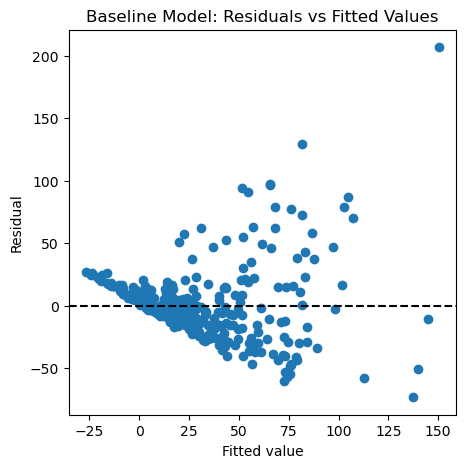

In [20]:
#plot the residual vs predicted value graph
ax = subplots(figsize=(5, 5))[1]

ax.scatter(
    baseline_results.fittedvalues,
    baseline_results.resid
)

# Add the horizontal residual = 0 line
ax.axhline(0, c="k", ls="--")

ax.set_xlabel("Fitted value")
ax.set_ylabel("Residual")
ax.set_title("Baseline Model: Residuals vs Fitted Values")

plt.show()

The residuals are generally distributed around zero, but the pattern is not completely random. The spread becomes wider as the fitted values increase, and several large positive residuals appear at higher fitted values. This suggests that the linearity assumption may not be fully satisfied and that the model fits high-revenue movies less accurately. If linearity is violated, the model may systematically overpredict or underpredict revenue in some ranges, produce biased predictions, and fail to capture nonlinear relationships between the predictors and opening-weekend revenue.

## Question 9. Calculate and interpret the Durbin-Watson statistic

In [ ]:
# Put residuals in release-date order before calculating the DW statistic.


dw_df = df.loc[baseline_data.index, ["release_date"]].copy()
dw_df["residual"] = baseline_results.resid
dw_df.sort_values("release_date").reset_index(drop=True)

dw_statistic = durbin_watson(dw_df["residual"])
print("Durbin-Watson statistic (release-date order):", round(dw_statistic, 4))
 

 

Durbin-Watson statistic (release-date order): 1.9503


After ordering the observations by release date, the Durbin-Watson statistic is 1.9503. Since this value is very close to 2, it suggests little or no autocorrelation among the residuals. In other words, the prediction error for one movie does not appear to be systematically related to the error for the movie released immediately before it. Therefore, the independence assumption appears reasonable for the baseline model.

## Question 10. Assess constant error variance using White's test

In [25]:
from statsmodels.stats.diagnostic import het_breuschpagan, het_white
white_test = het_white(baseline_results.resid, baseline_results.model.exog)

white_labels = ["LM statistic", "LM p-value", "F statistic", "F p-value"]

white_results = pd.Series(white_test, index=white_labels)
white_results


LM statistic    1.297007e+02
LM p-value      1.366475e-23
F statistic     2.210194e+01
F p-value       1.518326e-29
dtype: float64

The residual-versus-fitted plot shows that the residual spread generally increases as the fitted values increase, suggesting non-constant variance. In White’s test, the null hypothesis is that the errors have constant variance. The LM p-value is approximately 1.37 × 10⁻²³, so there is enough evidence to reject the null hypothesis at the 5% level and conclude that heteroskedasticity is present. If constant variance is violated, the OLS coefficient estimates may remain unbiased, but their standard errors, t-tests, p-values, and confidence intervals may be unreliable.

## Question 11. Assess normality using a Q-Q plot and the Shapiro-Wilk test

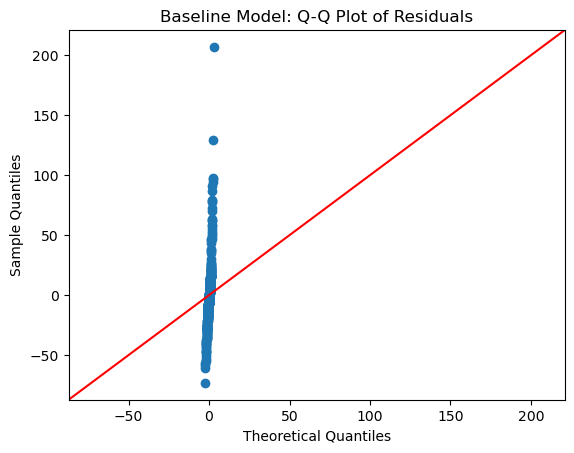

Shapiro-Wilk test statistic: 0.8597
Shapiro-Wilk test p-value: 0.0


In [28]:
sm.qqplot(baseline_results.resid, line="45")
plt.title("Baseline Model: Q-Q Plot of Residuals")
plt.show()

shapiro_result = shapiro(baseline_results.resid)
print("Shapiro-Wilk test statistic:", round(shapiro_result.statistic, 4))
print("Shapiro-Wilk test p-value:", round(shapiro_result.pvalue, 4))

The Q-Q plot shows substantial departures from the 45-degree line. The Shapiro-Wilk test gives W = 0.8597 and p≈0. The null hypothesis is that the residuals are normally distributed. Since the p-value is below 0.05, therefore, we reject the null hypothesis(Normality Assumption). Non-normal residuals can make t-tests, p-values, and confidence intervals less reliable, especially when the deviations are caused by extreme observations.

## Question 12. Identify high-leverage and influential observations

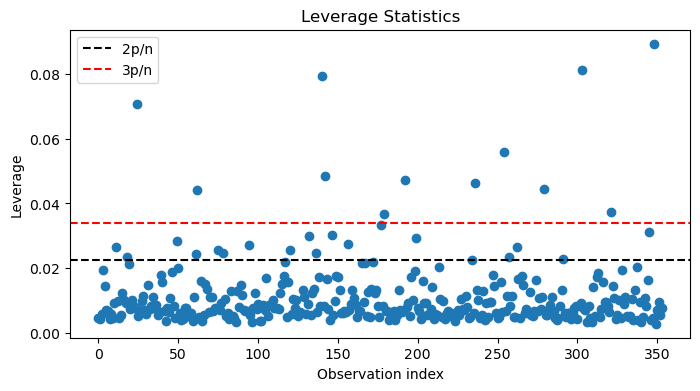

2p/n threshold: 0.0226
3p/n threshold: 0.0339
Movies above 2p/n: 30
Movies above 3p/n: 12
Movies above 4/n: 31


In [ ]:
# Leverage statistics, following the lecture.
influence = baseline_results.get_influence()
leverage = influence.hat_matrix_diag

n = X_baseline.shape[0]
p = X_baseline.shape[1]
leverage_2pn = 2 * p / n
leverage_3pn = 3 * p / n


fig, ax = subplots(figsize=(8, 4))
ax.scatter(np.arange(n), leverage)
ax.axhline(leverage_2pn, color="black", linestyle="--", label="2p/n")
ax.axhline(leverage_3pn, color="red", linestyle="--", label="3p/n")
ax.set_xlabel("Observation index")
ax.set_ylabel("Leverage")
ax.set_title("Leverage Statistics")
ax.legend()
plt.show()

print("2p/n threshold:", round(leverage_2pn, 4))
print("3p/n threshold:", round(leverage_3pn, 4))
print("Movies above 2p/n:", int((leverage > leverage_2pn).sum()))
print("Movies above 3p/n:", int((leverage > leverage_3pn).sum()))
print("Movies above 4/n:",int((cooks_distance > cook_threshold).sum()))


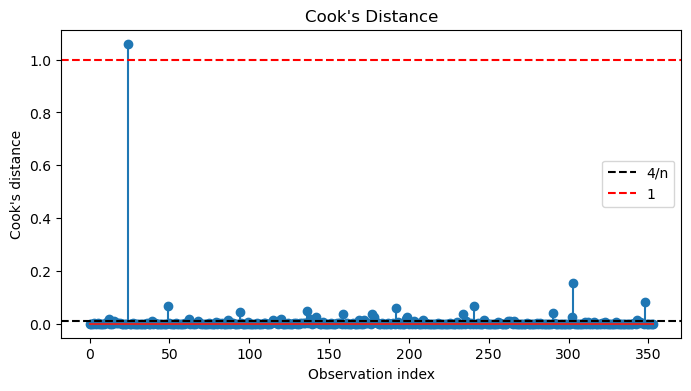

Movies with leverage above 3p/n:


,movie_id,title,production_budget_musd,opening_theaters,runtime_minutes,opening_weekend_revenue_musd,Leverage,Cook's distance
353,TRN-0384,Avatar: Fire and Ash,400.0,3800,197.0,89.1609,0.0894,0.0839
308,TRN-0333,Mission: Impossible—The Final Reckoning,400.0,3857,169.0,64.0364,0.0812,0.1559
143,TRN-0157,Avatar: The Way of Water,400.0,4202,190.0,134.1002,0.0795,0.0032
24,TRN-0029,Avengers: Endgame,400.0,4662,181.0,357.1150,0.0708,1.0604
259,TRN-0281,Devara Part 1,75.0,1040,178.0,5.6000,0.0560,0.0002
145,TRN-0159,Babylon,80.0,3343,188.0,3.6034,0.0484,0.0264
196,TRN-0215,TAYLOR SWIFT | THE ERAS TOUR,15.0,3855,168.0,93.2248,0.0474,0.0614
241,TRN-0261,Horizon: An American Saga Chapter 1,50.0,3334,181.0,11.0526,0.0464,0.0087
284,TRN-0308,Ne Zha 2,80.0,660,143.0,7.2000,0.0446,0.0007
62,TRN-0071,It: Chapter Two,70.0,4570,169.0,91.0622,0.0441,0.0176


Movies with Cook's distance above 4/n:


,movie_id,title,production_budget_musd,opening_theaters,runtime_minutes,opening_weekend_revenue_musd,Leverage,Cook's distance
24,TRN-0029,Avengers: Endgame,400.0,4662,181.0,357.1150,0.0708,1.0604
308,TRN-0333,Mission: Impossible—The Final Reckoning,400.0,3857,169.0,64.0364,0.0812,0.1559
353,TRN-0384,Avatar: Fire and Ash,400.0,3800,197.0,89.1609,0.0894,0.0839
49,TRN-0056,The Lion King,260.0,4725,118.0,191.7708,0.0283,0.0688
246,TRN-0267,Deadpool & Wolverine,200.0,4210,127.0,211.4353,0.0128,0.0668
196,TRN-0215,TAYLOR SWIFT | THE ERAS TOUR,15.0,3855,168.0,93.2248,0.0474,0.0614
139,TRN-0152,Black Panther: Wakanda Forever,250.0,4396,161.0,181.3398,0.0246,0.0485
94,TRN-0103,Star Wars: The Rise of Skywalker,275.0,4406,142.0,177.3839,0.0270,0.0425
295,TRN-0320,A Minecraft Movie,150.0,4263,100.0,162.7530,0.0134,0.0394
239,TRN-0259,Inside Out 2,200.0,4440,100.0,154.2017,0.0226,0.0374


Movies with Cook's distance above 1:


,movie_id,title,production_budget_musd,opening_theaters,runtime_minutes,opening_weekend_revenue_musd,Leverage,Cook's distance
24,TRN-0029,Avengers: Endgame,400.0,4662,181.0,357.115,0.0708,1.0604


In [34]:
# Cook's distance, following the lecture.
ols_influence = OLSInfluence(baseline_results)
cooks_distance, cooks_pvalue = ols_influence.cooks_distance
cook_threshold = 4 / n

fig, ax = subplots(figsize=(8,4))
ax.stem(np.arange(n), cooks_distance)
ax.axhline(cook_threshold, color="black", linestyle="--", label="4/n")
ax.axhline(1, color="red", linestyle="--", label="1")
ax.set_xlabel("Observation index")
ax.set_ylabel("Cook's distance")
ax.set_title("Cook's Distance")
ax.legend()
plt.show()

influence_table = df.loc[
    baseline_data.index,
    ["movie_id", "title",
     "production_budget_musd",
     "opening_theaters",
     "runtime_minutes",
     "opening_weekend_revenue_musd"]
].copy()
influence_table["Leverage"] = leverage
influence_table["Cook's distance"] = cooks_distance

very_high_leverage = influence_table[
   influence_table["Leverage"] > leverage_3pn
].sort_values("Leverage", ascending=False)#dataset with leverage greater than 3p/n

large_cook = influence_table[
    influence_table["Cook's distance"] > cook_threshold
].sort_values("Cook's distance", ascending=False) #dataset with leverage  greater than 4/n

serious_cook = influence_table[
    influence_table["Cook's distance"] > 1
].sort_values("Cook's distance", ascending=False)#dataset with leverage greater than 1



print("Movies with leverage above 3p/n:")
display(very_high_leverage.round(4))

print("Movies with Cook's distance above 4/n:")
display(large_cook.round(4))

print("Movies with Cook's distance above 1:")
display(serious_cook.round(4))

The leverage analysis identifies 30 observations above \(2p/n\) and 12 above \(3p/n\), indicating that these movies have unusual combinations of predictor values. Cook’s distance identifies 31 potentially influential observations above \(4/n\). Avengers: Endgame is serious outliers because their Cook’s distances exceed 1, meaning that removing them could substantially change the estimated regression coefficients. Overall, the baseline model has several weaknesses: the residuals are non-normal, the error variance is not constant, and influential observations may strongly affect the estimates. In addition, runtime is insignificant and the model explains only about 52.6% of the variation in opening-weekend revenue.

# Part 4. Design your own regression model

## Question 13. State Y and the candidate X variables before fitting models

## Question 14. Write and justify the final regression model

## Question 15. Describe and report the missing-value treatment

## Question 16. Create and display the y vector and X matrix

## Question 17. Estimate, report, and interpret the final model

## Question 18. Evaluate limitations and training-data prediction accuracy

# Part 5. Reflect on the use of AI